<table width="100%"><tr style="background-color:white;">
    <td style="text-align:left;padding:0px;width:142px'">
        <a href="https://qworld.net" target="_blank">
            <img src="../images/QWorld.png"></a></td>
    <td width="*">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</td>
    <!-- ############################################# -->
    <td style="padding:0px;width:90px;">
        <img align="right" src="../images/follow_us.png" height="40px"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://twitter.com/QWorld19" target="_blank">
        <img align="right" src="../images/Twitter.png" width="40px"></a> </td>
    <td style="padding:0px;width:5px;"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://www.facebook.com/qworld19/" target="_blank">
        <img align="right" src="../images/Fb.png"></a></td>
    <td style="padding:0px;width:5px;"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://www.linkedin.com/company/qworld19" target="_blank">
        <img align="right" src="../images/LinkedIn.png"></a></td>
    <td style="padding:0px;width:5px;"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://www.youtube.com/qworld19" target="_blank">
        <img align="right" src="../images/YT.png"></a></td>
    <!-- ############################################# -->
    <td style="padding:0px;width:60px;">
        <img align="right" src="../images/join.png" height="40px"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://discord.gg/akCvr7U87g"
           target="_blank">
        <img align="right" src="../images/Discord.png"></a></td>
    <!-- ############################################# -->
    <td style="padding:0px;width:72px;">
        <img align="right" src="../images/w3.png" height="40px"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://qworld.net" target="_blank">
        <img align="right" src="../images/www.png"></a></td>
</tr></table>

<table width = "100%">
  <tr style="background-color:white;">
    <td style="text-align:right;vertical-align:bottom;font-size:12px;"> 
        Prepared by Anastasija Trizna (QPoland, QLatvia), Wajeeha Sardar & Dr. Ayesha Khalique(QPakistan)</td>
    </tr>
    <tr><td align="right" style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;">
        This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros.
    </td></tr>
 </table>
 
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\vhadamardzero}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\vhadamardone}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $

 ---

# Six States Protocol with Eavesdropper
In this protocol, when Asja send the states, Eve will measure it and then will send it to the Balvis, which will introduce errors in the key.
When Asja send the state to Balvis, on the way Eve measures the states and then sends it to Balvis. You can implement this protocol by giving Eve the initial quantum circuit of Asja and giving Balvis the initial circuit of Eve.

**In this cell we will define some functions and will generate the random key with Asja, Eve and Balvis selecting basis randomly.**

In [1]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.compiler import transpile
from numpy import pi
from qiskit.quantum_info import Operator
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from random import randrange
import hashlib


def print_outcomes_in_reverse(counts): # takes a dictionary variable
    for outcome in counts: # for each key-value in dictionary
        reverse_outcome = ''
        for i in outcome: # each string can be considered as a list of characters
            reverse_outcome = i + reverse_outcome # each new symbol comes before the old symbol(s)
    return reverse_outcome

#Source for SendState: awards/teach_me_qiskit_2018/cryptography/Cryptography.ipynb
def SendState(qc1, qc2, q_name):
    """
    Copy X, H, S gates from qc1 into qc2.
    qc1 is assumed to contain only x, h, s (and possibly measurements).
    """

    for instruction, qargs, cargs in qc1.data:
        gate_name = instruction.name

        # get qubit index
        if len(qargs) > 0:
            qubit_index = qc1.find_bit(qargs[0]).index

        if gate_name == "x":
            qc2.x(qreg[qubit_index])

        elif gate_name == "h":
            qc2.h(qreg[qubit_index])

        elif gate_name == "s":
            qc2.s(qreg[qubit_index])

        elif gate_name == "measure":
            # ignore measurements
            continue

        else:
            raise Exception(f"Unsupported instruction: {gate_name}")


qreg = QuantumRegister(24) # quantum register with 24 qubits
creg = ClassicalRegister(24) # classical register with 24 bits

# Quantum circuit for Asja state
asja = QuantumCircuit(qreg, creg, name='Asja')

send=[] #Initial bit string to send
asja_basis=[] #Initial Asja Basis
balvis_basis=[] #Initial Balvis basis
eve_basis =[]

# Creating randomly chosen basis for Asja (X,Y,Z)
for i in range(24):
    a_b = randrange(3)
    asja_basis.append(a_b)
asja_basis = ['X' if x==1 else "Y" if x==0 else "Z" if x==2 else x for x in asja_basis]
print("Asja Basis:      ",asja_basis)


# Creating randomly chosen basis for Balvis (X,Y,Z)
for i in range(24):
    a_b = randrange(3)
    balvis_basis.append(a_b)
balvis_basis = ['X' if x==1 else "Y" if x==0 else "Z" if x==2 else x for x in balvis_basis]
print("Balvis Basis:        ",balvis_basis)

# Creating randomly chosen basis for Balvis (X,Y,Z)
for i in range(24):
    a_b = randrange(3)
    eve_basis.append(a_b)
eve_basis = ['X' if x==1 else "Y" if x==0 else "Z" if x==2 else x for x in balvis_basis]
print("Eve Basis:        ",eve_basis)


#Creating random bit string
for i in range(24):
    bit = randrange(2)
    send.append(bit)
print("The bits Asja wants to send:     ",send)

Asja Basis:       ['Y', 'X', 'Z', 'Z', 'Z', 'Z', 'Y', 'Y', 'X', 'X', 'Z', 'Y', 'X', 'Z', 'X', 'Y', 'Z', 'Z', 'Z', 'Z', 'Z', 'Y', 'Y', 'X']
Balvis Basis:         ['X', 'Y', 'X', 'Y', 'Z', 'Z', 'Z', 'Y', 'X', 'Z', 'Y', 'X', 'Z', 'Z', 'X', 'Z', 'Y', 'X', 'X', 'Y', 'Z', 'Y', 'X', 'X']
Eve Basis:         ['X', 'Y', 'X', 'Y', 'Z', 'Z', 'Z', 'Y', 'X', 'Z', 'Y', 'X', 'Z', 'Z', 'X', 'Z', 'Y', 'X', 'X', 'Y', 'Z', 'Y', 'X', 'X']
The bits Asja wants to send:      [1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]


**Asja will apply the corresponding gates as her basis.**

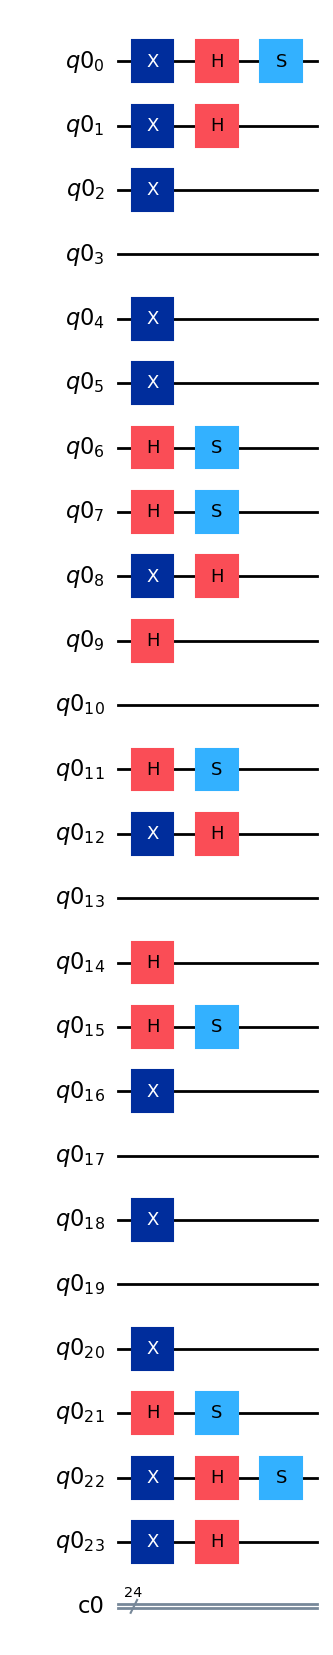

In [ ]:
#Apply X gate if bit is equal to 1
for i, n in enumerate(send):
    if n==1:
        asja.x(qreg[i]) # apply x-gate
for i, k in enumerate(asja_basis): 
    if k=='X':
        asja.h(qreg[i])
    if k=="Y":
        asja.h(qreg[i])
        asja.s([qreg[i]])
            
        send_str = ''.join(str(e) for e in send)

asja.draw("mpl") #To check gates applied correctly

**The states are send and Eve inturrepts the channel and measure the states.**

C:\Users\LAPTOP CHANNEL\AppData\Local\Temp\ipykernel_7276\501699167.py:25: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instruction, qargs, cargs in qc1.data:


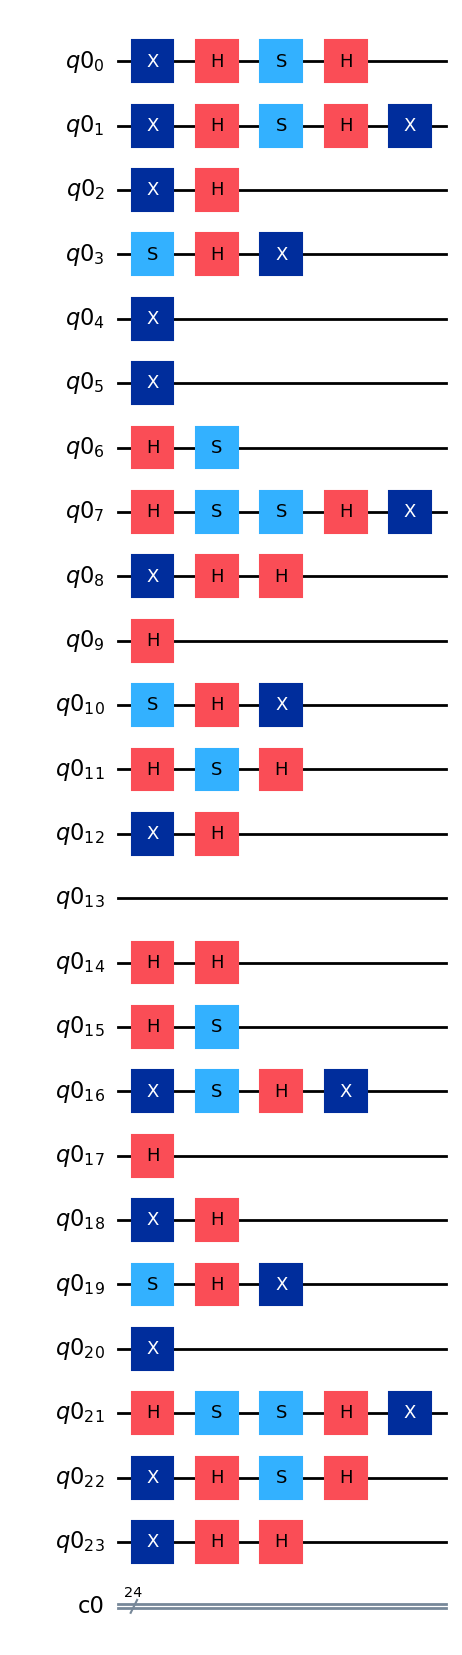

In [3]:
eve = QuantumCircuit(qreg, creg, name='Eve') #Defining Balvis circuit
SendState(asja, eve, 'Asja') #Asja sends states to Balvis

for i, k in enumerate(eve_basis): 
    if k=='X':
        eve.h(qreg[i])
    if k=="Y":
        eve.s(qreg[i])
        eve.h(qreg[i])
        eve.x(qreg[i])
            

eve.draw("mpl")

**Eve sends the measured state to Balvis and then Balvis measures the states according to his randomly generated basis.**

C:\Users\LAPTOP CHANNEL\AppData\Local\Temp\ipykernel_7276\501699167.py:25: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instruction, qargs, cargs in qc1.data:


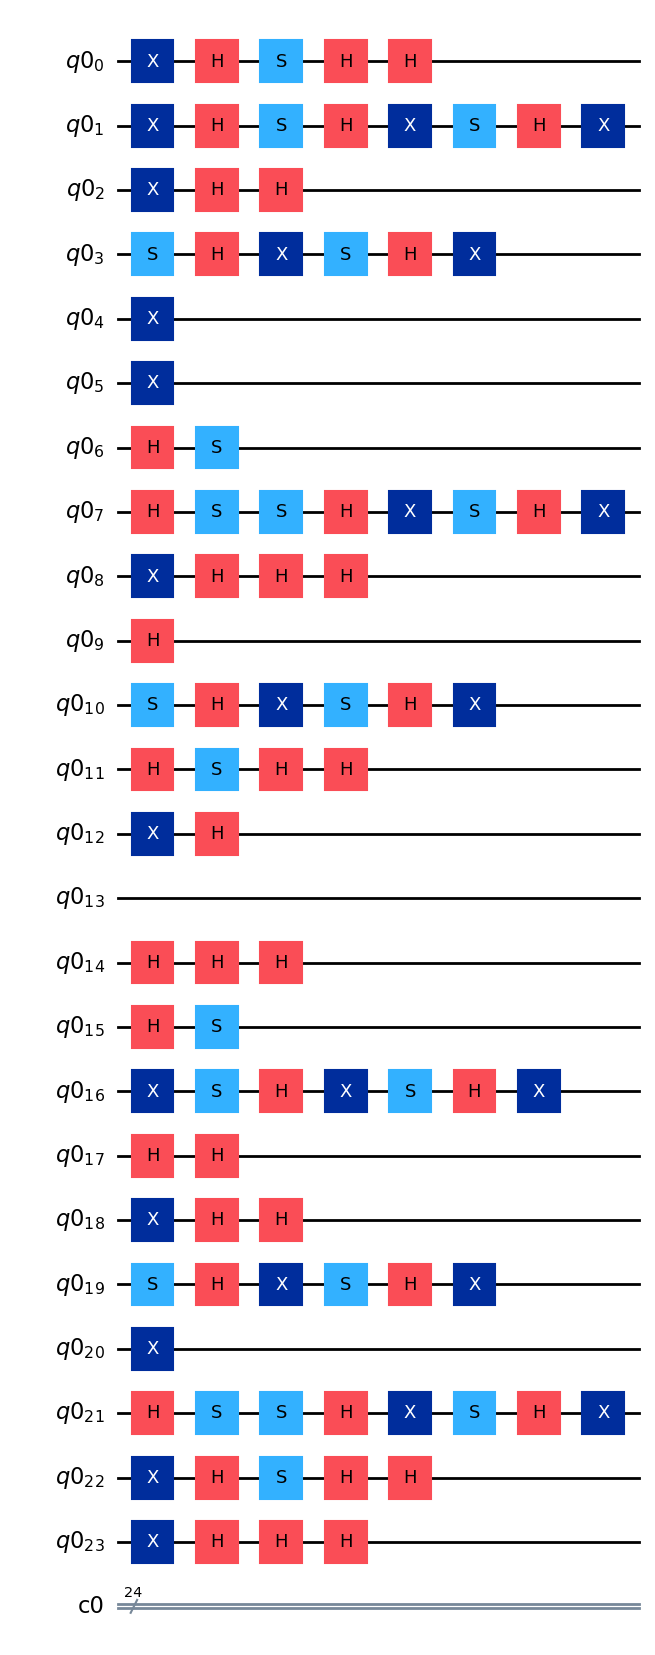

In [4]:
balvis = QuantumCircuit(qreg, creg, name='Balvis') #Defining Balvis circuit
SendState(eve, balvis, 'Asja') #Asja sends states to Balvis

for i, k in enumerate(balvis_basis): 
    if k=='X':
        balvis.h(qreg[i])
    if k=="Y":
        balvis.s(qreg[i])
        balvis.h(qreg[i])
        balvis.x(qreg[i])

balvis.draw("mpl")

**Balvis measures the states in computational basis.**

In [5]:
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile

# measurement (same)
balvis.measure(qreg, creg)

# create simulator backend
sim = AerSimulator()

# transpile circuit for simulator
compiled_circuit = transpile(balvis, sim)

# run simulation
job = sim.run(compiled_circuit, shots=1000)
result = job.result()

# get counts
counts = result.get_counts()

received = print_outcomes_in_reverse(counts)

print("Asja sent:", send_str)
print("Balvis received:", received)

Asja sent: 111011001000100010101011
Balvis received: 011011011011101100101000


**With classical communication Balvis and Asja will compare the basis.**

In [6]:

asja_key=[] #Asjas register for matching rounds
balvis_key=[] #Balvis register for matching rounds
for j in range(0,len(asja_basis)): #Going through list of bases 
    if asja_basis[j] == balvis_basis[j]: #Comparing
        asja_key.append(send[j])
        balvis_key.append(received[j]) #Keeping key bit if bases matched
    else:
        pass #Discard round if bases mismatched
balvis_key = [eval(i) for i in balvis_key]

print("Asjas key =", asja_key)
print("Balvis key =", balvis_key)
        

Asjas key = [1, 1, 0, 1, 0, 0, 1, 0, 1]
Balvis key = [1, 1, 1, 1, 0, 1, 1, 0, 0]


**Error Correction**

In [9]:
rounds = len(asja_key)//3    #To divide without remainer, use //

errors=0
for i in range(rounds):
    bit_index = randrange(len(asja_key)) 
    
    tested_bit = asja_key[bit_index]
    print ("Asja randomly selected bit index =", bit_index, ", and its value is = ", tested_bit)
    if asja_key[bit_index]!=balvis_key[bit_index]: #comparing tested rounds
        errors=errors+1 #calculating errors
    #removing tested bits from key strings
    del asja_key[bit_index] #Use del to specify the index of the element you want to delete
    del balvis_key[bit_index]
if rounds!=0:
    QBER=errors/rounds #calculating QBER
else:
    print("the key is too short for privacy amplification ")       
print("QBER value =", QBER)
print("Asjas secret key =", asja_key)
print("Balvis secret key =", balvis_key)
print("Number of errors = ", errors)

Asja randomly selected bit index = 0 , and its value is =  0
QBER value = 1.0
Asjas secret key = [0, 1, 0]
Balvis secret key = [0, 1, 0]
Number of errors =  1


### Information Recociliation
Again the keys may not be same, so we have to do the classical methods of information reconciliation and privacy ampification to get the same keys. 